# Cross-channel distance-sampling figure

This notebook prepares matched WT split-violin panels for a manuscript figure. Each panel compares WT vanilla and WT targeted-masked predictions using the final channel-specific QC subset. The manuscript row order is Kv2.1, NaV1.5, and CaV1.2. Experimental markers use the same PDB-specific colors and shapes as the channel notebooks.

The recommended main figure contains the voltage-sensor and intracellular-gate columns. These are the regions that most directly test whether masking changes access to alternative channel geometries. The selectivity-filter column is exported as a matched structural control and is better suited to a supplementary or extended-data figure.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from IPython.display import display

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'shared').is_dir())
sys.path.insert(0, str(repo_root))

from shared.cross_channel_distance_figure import (
    load_paper_data, make_grid, make_individual_panels, paper_configs,
)

configs = paper_configs(repo_root)
data = load_paper_data(configs)
figures = repo_root / 'docs' / 'figures' / 'cross_channel_distance_sampling'
figures.mkdir(parents=True, exist_ok=True)

for channel, config in configs.items():
    print(f"{channel}: {config['condition']} | vanilla={len(data[channel]['vanilla'])} | masked={len(data[channel]['masked'])}")

Kv2.1: WT | vanilla=4562 | masked=3658
Nav1.5: WT | mask v2 | vanilla=5000 | masked=4999
Cav1.2: WT | vanilla=5000 | masked=4996


## Recommended main figure

Only WT ensembles are shown at this stage. Rows follow the manuscript order: Kv2.1, NaV1.5, and CaV1.2. Columns move from the intracellular activation gate to the selectivity filter and then the voltage sensors, so pore opening, pore integrity, and voltage-sensor variability can be read from left to right. All panels use the final channel-specific QC subsets and identical dimensions.

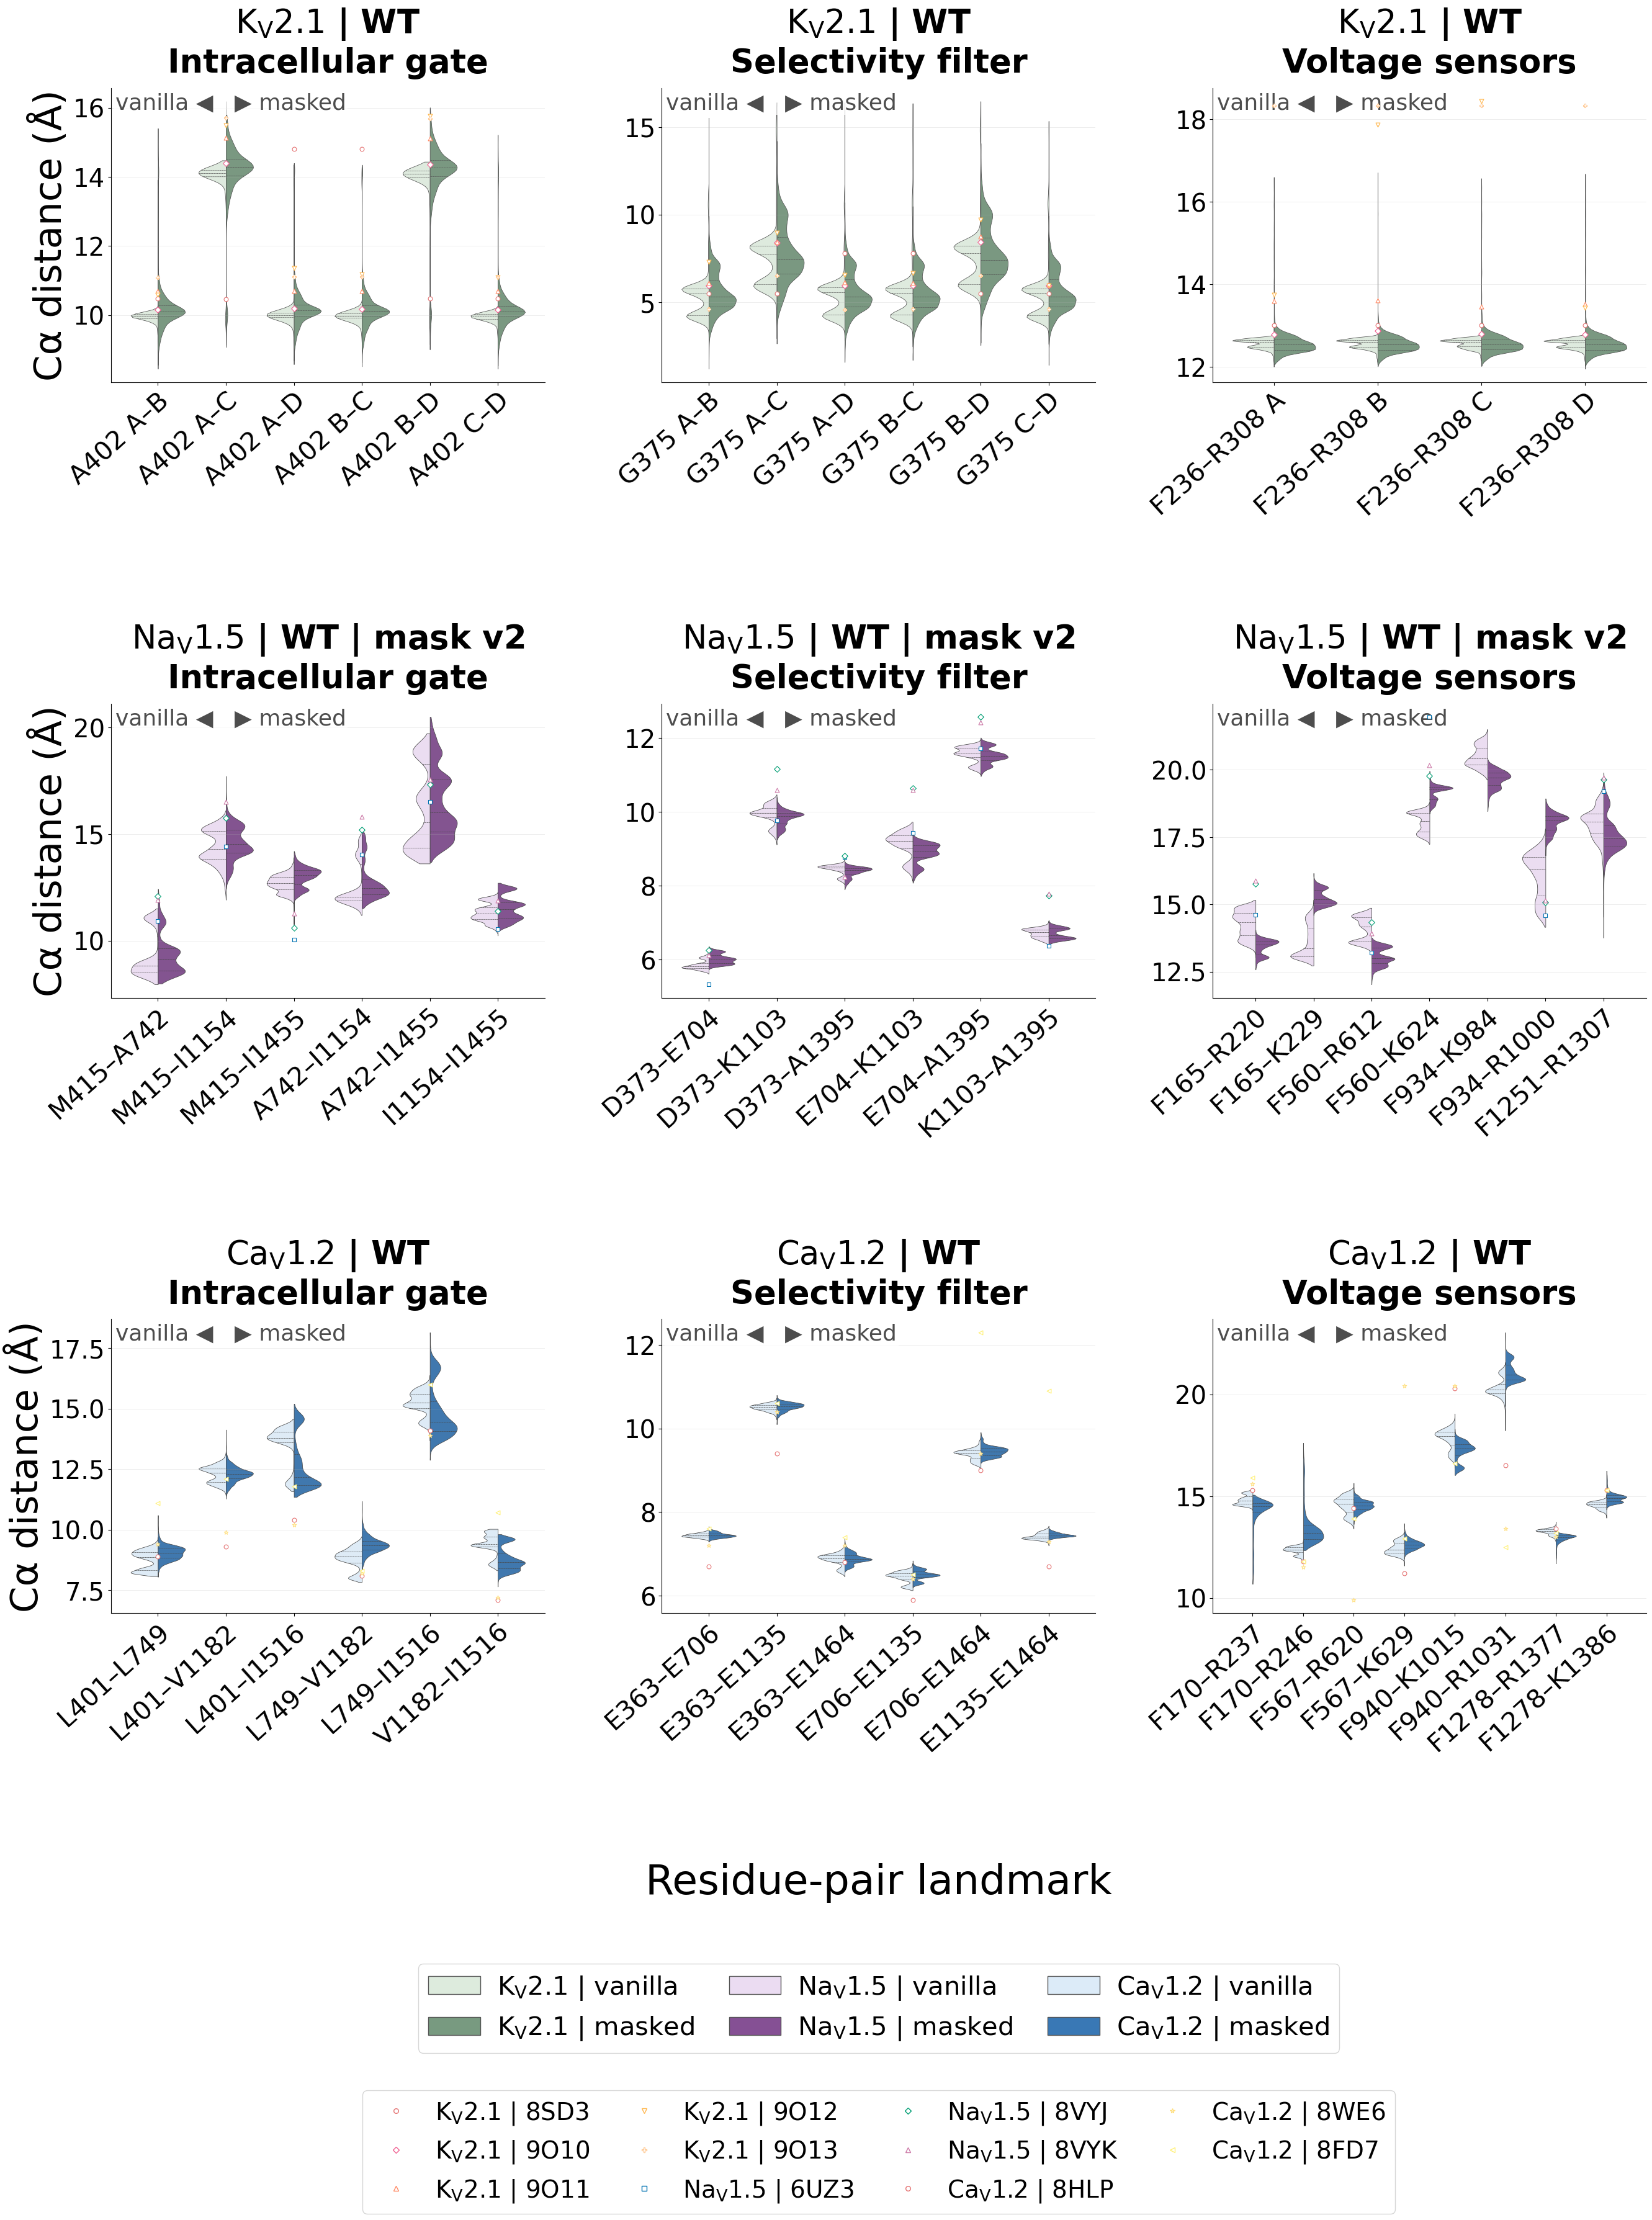

In [2]:
main_figure = make_grid(
    repo_root, configs, data,
    regions=('intracellular_gate', 'selectivity_filter', 'vsds'),
    output_path=figures / 'cross_channel_main_gate_filter_vsd.png',
)
display(main_figure)
plt.close(main_figure)

## Equal-size panel exports

Every channel–region panel below is exported at the same physical dimensions and resolution. These files can be placed directly into a manuscript table or rearranged without rescaling one channel relative to another.

In [3]:
panel_paths = make_individual_panels(repo_root, configs, data, figures / 'individual_panels')
print(f'Exported {len(panel_paths)} equal-size panels')
for path in panel_paths:
    print(path.relative_to(repo_root))

Exported 9 equal-size panels
docs/figures/cross_channel_distance_sampling/individual_panels/kv21_wt_selectivity_filter.png
docs/figures/cross_channel_distance_sampling/individual_panels/kv21_wt_vsds.png
docs/figures/cross_channel_distance_sampling/individual_panels/kv21_wt_intracellular_gate.png
docs/figures/cross_channel_distance_sampling/individual_panels/nav15_wt_selectivity_filter.png
docs/figures/cross_channel_distance_sampling/individual_panels/nav15_wt_vsds.png
docs/figures/cross_channel_distance_sampling/individual_panels/nav15_wt_intracellular_gate.png
docs/figures/cross_channel_distance_sampling/individual_panels/cav12_wt_selectivity_filter.png
docs/figures/cross_channel_distance_sampling/individual_panels/cav12_wt_vsds.png
docs/figures/cross_channel_distance_sampling/individual_panels/cav12_wt_intracellular_gate.png
